In [2]:
import numpy as np
import pyemma

In [3]:
np.random.seed(0)
fake_trajectory = np.random.choice([0, 1, 2], size=1000, p=[0.6, 0.3, 0.1])

In [4]:
from pyemma.msm import estimate_markov_model
msm = estimate_markov_model(fake_trajectory, lag=1)

In [5]:
print("Transition matrix:")
print(msm.transition_matrix)
print("\nStationary distribution:")
print(msm.stationary_distribution)

Transition matrix:
[[0.60983607 0.28433688 0.10582705]
 [0.61407296 0.27402135 0.11190569]
 [0.59671759 0.2921713  0.11111111]]

Stationary distribution:
[0.60961373 0.28227211 0.10811416]


In [6]:
msm_lag5 = estimate_markov_model(fake_trajectory, lag=5)
print("Transition matrix (lag=5):")
print(msm_lag5.transition_matrix)
print("\nStationary distribution (lag=5):")
print(msm_lag5.stationary_distribution)

Transition matrix (lag=5):
[[0.62108731 0.27711308 0.1017996 ]
 [0.60068455 0.28469751 0.11461794]
 [0.57203403 0.29712484 0.13084112]]

Stationary distribution (lag=5):
[0.61002036 0.28141996 0.10855968]


In [7]:
# A trajectory where state 0 tends to stay in itself (a "trap")
fake_sticky = []
state = 0
for _ in range(1000):
    fake_sticky.append(state)
    if state == 0:
        state = np.random.choice([0, 1], p=[0.9, 0.1])  # sticky trap
    else:
        state = np.random.choice([0, 1, 2], p=[0.3, 0.3, 0.4])

fake_sticky = np.array(fake_sticky)
msm_sticky = estimate_markov_model(fake_sticky, lag=1)
print(msm_sticky.transition_matrix)

[[0.8697479  0.10714286 0.02310924]
 [0.47222222 0.16666667 0.36111111]
 [0.13414634 0.47560976 0.3902439 ]]


In [8]:
import numpy as np
import scipy.linalg as la

In [9]:
# Simple 3-node graph: 0 -- 1 -- 2, with 0 being a "trap"
# Adjacency matrix
A = np.array([
    [0, 1, 0],
    [1, 0, 1],
    [0, 1, 0]
])

# Graph Laplacian: L = D - A
D = np.diag(A.sum(axis=1))
L = D - A
print("Laplacian:")
print(L)

Laplacian:
[[ 1 -1  0]
 [-1  2 -1]
 [ 0 -1  1]]


In [10]:
# Classical continuous-time random walk: dp/dt = -L p
# Solution: p(t) = exp(-Lt) p(0)
p0 = np.array([1.0, 0.0, 0.0])  # start fully at node 0
for t in [0, 1, 2, 5, 10]:
    p_t = la.expm(-L * t) @ p0
    print(f"t={t}: {p_t}")

t=0: [1. 0. 0.]
t=1: [0.5255709  0.31673764 0.15769146]
t=2: [0.4014141  0.33250708 0.26607882]
t=5: [0.33670236 0.33333323 0.32996441]
t=10: [0.33335603 0.33333333 0.33331063]


In [11]:
import numpy as np
import scipy.linalg as la

# Same 3-node graph as before
A = np.array([
    [0, 1, 0],
    [1, 0, 1],
    [0, 1, 0]
])

D = np.diag(A.sum(axis=1))
L = D - A

# Classical
p0 = np.array([1.0, 0.0, 0.0])
print("Classical diffusion:")
for t in [0, 1, 2, 5, 10]:
    p_t = la.expm(-L * t) @ p0
    print(f"t={t}: {np.round(p_t, 3)}")

# Quantum — only change is -1j
psi0 = np.array([1.0+0j, 0.0+0j, 0.0+0j])
print("\nQuantum walk:")
for t in [0, 1, 2, 5, 10]:
    psi_t = la.expm(-1j * L * t) @ psi0
    prob_t = np.abs(psi_t)**2
    print(f"t={t}: {np.round(prob_t, 3)}")

Classical diffusion:
t=0: [1. 0. 0.]
t=1: [0.526 0.317 0.158]
t=2: [0.401 0.333 0.266]
t=5: [0.337 0.333 0.33 ]
t=10: [0.333 0.333 0.333]

Quantum walk:
t=0: [1. 0. 0.]
t=1: [0.39  0.442 0.168]
t=2: [0.248 0.009 0.743]
t=5: [0.259 0.391 0.35 ]
t=10: [0.194 0.188 0.618]


In [12]:
import numpy as np
from scipy.linalg import expm


In [13]:

# Node 0 = native state, Node 1 = trap, Node 2 = connector
# Adjacency matrix: weight = transition rate between nodes
# Make it asymmetric: easy to enter trap, hard to leave it

A = np.array([
    [0.0, 0.1, 0.3],   # node 0 (native): weak link to trap, decent link to connector
    [0.1, 0.0, 0.05],  # node 1 (trap): weak links out both directions <- the trap
    [0.3, 0.05, 0.0],  # node 2 (connector): strong link to native, weak to trap
])

# Degree matrix (row sum — standard for graph Laplacian)
D = np.diag(A.sum(axis=1))

# Laplacian
L = D - A

print("Adjacency A:\n", A)
print("Degree D:\n", D)
print("Laplacian L:\n", L)

# Initial state: all probability/amplitude starts at native state (node 0)
p0 = np.array([1.0, 0.0, 0.0])
psi0 = np.array([1.0+0j, 0.0+0j, 0.0+0j])

timesteps = [0, 1, 2, 5, 10, 20]

print("\nClassical diffusion:")
for t in timesteps:
    p_t = expm(-L * t) @ p0
    print(f"t={t}: {np.round(p_t, 3)}")

print("\nQuantum walk:")
for t in timesteps:
    psi_t = expm(-1j * L * t) @ psi0
    prob_t = np.abs(psi_t) ** 2
    print(f"t={t}: {np.round(prob_t, 3)}")

Adjacency A:
 [[0.   0.1  0.3 ]
 [0.1  0.   0.05]
 [0.3  0.05 0.  ]]
Degree D:
 [[0.4  0.   0.  ]
 [0.   0.15 0.  ]
 [0.   0.   0.35]]
Laplacian L:
 [[ 0.4  -0.1  -0.3 ]
 [-0.1   0.15 -0.05]
 [-0.3  -0.05  0.35]]

Classical diffusion:
t=0: [1. 0. 0.]
t=1: [0.705 0.083 0.212]
t=2: [0.549 0.141 0.31 ]
t=5: [0.39 0.24 0.37]
t=10: [0.347 0.303 0.35 ]
t=20: [0.335 0.33  0.335]

Quantum walk:
t=0: [1. 0. 0.]
t=1: [0.999 0.    0.001]
t=2: [0.653 0.035 0.312]
t=5: [0.023 0.124 0.853]
t=10: [0.688 0.262 0.05 ]
t=20: [0.477 0.193 0.33 ]


In [14]:
import numpy as np
from scipy.linalg import expm

# Directed asymmetric graph
# Convention: A[i, j] = rate of flow FROM j TO i (so column j = "outgoing from j")
# Node 0 = native, Node 1 = trap, Node 2 = connector

A = np.array([
    #   from 0   from 1   from 2
    [   0.0,     0.02,    0.3   ],  # into node 0 (native)
    [   0.3,     0.0,     0.25  ],  # into node 1 (trap) <- easy to fall in (0.3, 0.25)
    [   0.1,     0.02,    0.0   ],  # into node 2 (connector)
])
# Notice: A[1,0]=0.3 (native->trap, easy in) vs A[0,1]=0.02 (trap->native, hard out)

# Out-degree: total rate LEAVING each node = column sum
out_degree = A.sum(axis=0)
D = np.diag(out_degree)

# Laplacian: L = D - A  (now asymmetric)
L = D - A

print("Adjacency A:\n", A)
print("Out-degree D:\n", D)
print("Laplacian L:\n", L)

p0 = np.array([1.0, 0.0, 0.0])
psi0 = np.array([1.0+0j, 0.0+0j, 0.0+0j])

timesteps = [0, 1, 2, 5, 10, 20, 40]

print("\nClassical diffusion:")
for t in timesteps:
    p_t = expm(-L * t) @ p0
    print(f"t={t}: {np.round(p_t, 3)}")

print("\nQuantum walk:")
for t in timesteps:
    psi_t = expm(-1j * L * t) @ psi0
    prob_t = np.abs(psi_t) ** 2
    print(f"t={t}: {np.round(prob_t, 3)}")

Adjacency A:
 [[0.   0.02 0.3 ]
 [0.3  0.   0.25]
 [0.1  0.02 0.  ]]
Out-degree D:
 [[0.4  0.   0.  ]
 [0.   0.04 0.  ]
 [0.   0.   0.55]]
Laplacian L:
 [[ 0.4  -0.02 -0.3 ]
 [-0.3   0.04 -0.25]
 [-0.1  -0.02  0.55]]

Classical diffusion:
t=0: [1. 0. 0.]
t=1: [0.682 0.253 0.065]
t=2: [0.483 0.431 0.086]
t=5: [0.211 0.712 0.077]
t=10: [0.102 0.844 0.054]
t=20: [0.079 0.874 0.046]
t=40: [0.078 0.876 0.046]

Quantum walk:
t=0: [1. 0. 0.]
t=1: [0.999 0.    0.   ]
t=2: [0.865 0.341 0.036]
t=5: [0.397 1.627 0.142]
t=10: [0.072 2.789 0.172]
t=20: [0.955 0.062 0.013]
t=40: [0.831 0.24  0.05 ]


In [15]:
import numpy as np
from scipy.linalg import expm

# Base symmetrized Hamiltonian (from before)
A_classical = np.array([
    [0.0,  0.02, 0.3 ],
    [0.3,  0.0,  0.25],
    [0.1,  0.02, 0.0 ],
])
A_quantum = (A_classical + A_classical.T) / 2
D_quantum = np.diag(A_quantum.sum(axis=1))
L_quantum = D_quantum - A_quantum

def perturbation_diagonal(L, trap_node, strength):
    """Raise the trap node's own energy."""
    L_pert = L.copy()
    L_pert[trap_node, trap_node] += strength
    return L_pert

def perturbation_offdiag(L, trap_node, target_node, strength):
    """Strengthen coupling between trap and a neighbor — open an escape channel."""
    L_pert = L.copy()
    L_pert[trap_node, target_node] -= strength
    L_pert[target_node, trap_node] -= strength
    # keep row sums at zero so it stays a valid Laplacian-like operator
    L_pert[trap_node, trap_node] += strength
    L_pert[target_node, target_node] += strength
    return L_pert

def run_ctqw_with_perturbation(L_base, perturb_fn, period, pulse_width, total_time, dt, psi0):
    """
    Evolve CTQW, periodically swapping in a perturbed Hamiltonian.
    period: how often perturbation fires (in time units)
    pulse_width: how long each firing lasts
    """
    psi = psi0.copy()
    t = 0.0
    trajectory = []
    while t < total_time:
        # Determine if we're inside a perturbation pulse
        phase = t % period
        active = phase < pulse_width
        L_now = perturb_fn() if active else L_base
        psi = expm(-1j * L_now * dt) @ psi
        t += dt
        trajectory.append((t, np.abs(psi)**2))
    return trajectory

psi0 = np.array([1.0+0j, 0.0+0j, 0.0+0j])
trap_node = 1
strength = 0.3
period = 5.0       # fires every 5 time units (placeholder for ~1-2s ATP cycle, scaled to your units)
pulse_width = 1.0  # perturbation active for 1 time unit each cycle
total_time = 20.0
dt = 0.5

# Variant A: diagonal
traj_diag = run_ctqw_with_perturbation(
    L_quantum,
    lambda: perturbation_diagonal(L_quantum, trap_node, strength),
    period, pulse_width, total_time, dt, psi0
)

# Variant B: off-diagonal (push trap -> node 0, the native state)
traj_offdiag = run_ctqw_with_perturbation(
    L_quantum,
    lambda: perturbation_offdiag(L_quantum, trap_node, 0, strength),
    period, pulse_width, total_time, dt, psi0
)

print("Diagonal perturbation — probability at trap node (1) over time:")
for t, p in traj_diag[::4]:
    print(f"t={t:.1f}: {np.round(p, 3)}  sum={p.sum():.3f}")

print("\nOff-diagonal perturbation — probability at trap node (1) over time:")
for t, p in traj_offdiag[::4]:
    print(f"t={t:.1f}: {np.round(p, 3)}  sum={p.sum():.3f}")

Diagonal perturbation — probability at trap node (1) over time:
t=0.5: [1. 0. 0.]  sum=1.000
t=2.5: [1. 0. 0.]  sum=1.000
t=4.5: [1. 0. 0.]  sum=1.000
t=6.5: [0.999 0.    0.001]  sum=1.000
t=8.5: [0.998 0.001 0.001]  sum=1.000
t=10.5: [0.997 0.001 0.002]  sum=1.000
t=12.5: [0.996 0.001 0.002]  sum=1.000
t=14.5: [0.995 0.002 0.003]  sum=1.000
t=16.5: [0.994 0.002 0.004]  sum=1.000
t=18.5: [0.992 0.003 0.005]  sum=1.000

Off-diagonal perturbation — probability at trap node (1) over time:
t=0.5: [1. 0. 0.]  sum=1.000
t=2.5: [0.998 0.002 0.   ]  sum=1.000
t=4.5: [0.998 0.002 0.   ]  sum=1.000
t=6.5: [0.992 0.007 0.001]  sum=1.000
t=8.5: [0.991 0.007 0.001]  sum=1.000
t=10.5: [0.986 0.011 0.002]  sum=1.000
t=12.5: [0.98  0.016 0.003]  sum=1.000
t=14.5: [0.978 0.018 0.004]  sum=1.000
t=16.5: [0.966 0.029 0.005]  sum=1.000
t=18.5: [0.963 0.03  0.007]  sum=1.000


In [16]:
import numpy as np
from scipy.linalg import expm

A_classical = np.array([
    [0.0,  0.02, 0.3 ],
    [0.3,  0.0,  0.25],
    [0.1,  0.02, 0.0 ],
])
D_classical = np.diag(A_classical.sum(axis=0))
L_classical = D_classical - A_classical

A_quantum = (A_classical + A_classical.T) / 2
D_quantum = np.diag(A_quantum.sum(axis=1))
L_quantum = D_quantum - A_quantum

def perturbation_diagonal(L, trap_node, strength):
    L_pert = L.copy()
    L_pert[trap_node, trap_node] += strength
    return L_pert

def perturbation_offdiag(L, trap_node, target_node, strength):
    L_pert = L.copy()
    L_pert[trap_node, target_node] -= strength
    L_pert[target_node, trap_node] -= strength
    L_pert[trap_node, trap_node] += strength
    L_pert[target_node, target_node] += strength
    return L_pert

def run_ctqw_with_perturbation(L_base, perturb_fn, period, pulse_width, total_time, dt, psi0):
    psi = psi0.copy()
    t = 0.0
    trajectory = []
    while t < total_time:
        phase = t % period
        active = phase < pulse_width
        L_now = perturb_fn() if active else L_base
        psi = expm(-1j * L_now * dt) @ psi
        t += dt
        trajectory.append((t, np.abs(psi)**2))
    return trajectory

trap_node = 1
strength = 0.3

# Start population trapped at node 1
psi0_trapped = np.array([0.0+0j, 1.0+0j, 0.0+0j])
p0_trapped = np.array([0.0, 1.0, 0.0])

# Classical: does probability at native (node 0) recover over time?
print("Classical diffusion — probability at native node (0):")
for t in [0, 1, 2, 5, 10, 20]:
    p_t = expm(-L_classical * t) @ p0_trapped
    print(f"t={t}: native={p_t[0]:.3f}  full={np.round(p_t,3)}")

# Plain CTQW (no perturbation)
print("\nPlain CTQW — probability at native node (0):")
traj_plain = run_ctqw_with_perturbation(
    L_quantum, lambda: L_quantum,  # perturb_fn just returns base, i.e. no perturbation
    period=999, pulse_width=0, total_time=20, dt=0.5, psi0=psi0_trapped
)
for t, p in traj_plain[::4]:
    print(f"t={t:.1f}: native={p[0]:.3f}  full={np.round(p,3)}  sum={p.sum():.3f}")

# CTQW + diagonal perturbation
traj_diag = run_ctqw_with_perturbation(
    L_quantum, lambda: perturbation_diagonal(L_quantum, trap_node, strength),
    period=5.0, pulse_width=1.0, total_time=20, dt=0.5, psi0=psi0_trapped
)
print("\nCTQW + diagonal perturbation — probability at native node (0):")
for t, p in traj_diag[::4]:
    print(f"t={t:.1f}: native={p[0]:.3f}  full={np.round(p,3)}  sum={p.sum():.3f}")

# CTQW + off-diagonal perturbation
traj_offdiag = run_ctqw_with_perturbation(
    L_quantum, lambda: perturbation_offdiag(L_quantum, trap_node, 0, strength),
    period=5.0, pulse_width=1.0, total_time=20, dt=0.5, psi0=psi0_trapped
)
print("\nCTQW + off-diagonal perturbation — probability at native node (0):")
for t, p in traj_offdiag[::4]:
    print(f"t={t:.1f}: native={p[0]:.3f}  full={np.round(p,3)}  sum={p.sum():.3f}")

Classical diffusion — probability at native node (0):
t=0: native=0.000  full=[0. 1. 0.]
t=1: native=0.018  full=[0.018 0.966 0.016]
t=2: native=0.033  full=[0.033 0.941 0.026]
t=5: native=0.060  full=[0.06  0.9   0.039]
t=10: native=0.075  full=[0.075 0.88  0.045]
t=20: native=0.078  full=[0.078 0.876 0.046]

Plain CTQW — probability at native node (0):
t=0.5: native=0.000  full=[0. 1. 0.]  sum=1.000
t=2.5: native=0.000  full=[0. 1. 0.]  sum=1.000
t=4.5: native=0.000  full=[0. 1. 0.]  sum=1.000
t=6.5: native=0.000  full=[0. 1. 0.]  sum=1.000
t=8.5: native=0.000  full=[0. 1. 0.]  sum=1.000
t=10.5: native=0.001  full=[0.001 0.999 0.   ]  sum=1.000
t=12.5: native=0.001  full=[0.001 0.999 0.   ]  sum=1.000
t=14.5: native=0.001  full=[0.001 0.999 0.   ]  sum=1.000
t=16.5: native=0.001  full=[0.001 0.998 0.   ]  sum=1.000
t=18.5: native=0.002  full=[0.002 0.998 0.   ]  sum=1.000

CTQW + diagonal perturbation — probability at native node (0):
t=0.5: native=0.000  full=[0. 1. 0.]  sum=1.000
t

In [17]:
import numpy as np
from scipy.linalg import expm

# 4-node graph: 0=native, 1=trap, 2=short path, 3=long/indirect path
# A[i,j] = rate from j into i

A_classical = np.array([
    #   from0  from1  from2  from3
    [   0.0,   0.02,  0.35,  0.05 ],  # into native (0)
    [   0.3,   0.0,   0.05,  0.02 ],  # into trap (1) <- easy in, hard out
    [   0.1,   0.25,  0.0,   0.15 ],  # into short path (2)
    [   0.05,  0.15,  0.1,   0.0  ],  # into long path (3)
])

D_classical = np.diag(A_classical.sum(axis=0))
L_classical = D_classical - A_classical

A_quantum = (A_classical + A_classical.T) / 2
D_quantum = np.diag(A_quantum.sum(axis=1))
L_quantum = D_quantum - A_quantum

def perturbation_diagonal(L, trap_node, strength):
    L_pert = L.copy()
    L_pert[trap_node, trap_node] += strength
    return L_pert

def perturbation_offdiag(L, trap_node, target_node, strength):
    L_pert = L.copy()
    L_pert[trap_node, target_node] -= strength
    L_pert[target_node, trap_node] -= strength
    L_pert[trap_node, trap_node] += strength
    L_pert[target_node, target_node] += strength
    return L_pert

def run_ctqw_with_perturbation(L_base, perturb_fn, period, pulse_width, total_time, dt, psi0):
    psi = psi0.copy()
    t = 0.0
    trajectory = []
    while t < total_time:
        phase = t % period
        active = phase < pulse_width
        L_now = perturb_fn() if active else L_base
        psi = expm(-1j * L_now * dt) @ psi
        t += dt
        trajectory.append((t, np.abs(psi)**2))
    return trajectory

trap_node = 1
strength = 0.3
psi0_trapped = np.array([0.0+0j, 1.0+0j, 0.0+0j, 0.0+0j])
p0_trapped = np.array([0.0, 1.0, 0.0, 0.0])

print("Classical diffusion — probability at native (0):")
for t in [0, 1, 2, 5, 10, 20]:
    p_t = expm(-L_classical * t) @ p0_trapped
    print(f"t={t}: native={p_t[0]:.3f}  full={np.round(p_t,3)}")

print("\nPlain CTQW — probability at native (0):")
traj_plain = run_ctqw_with_perturbation(
    L_quantum, lambda: L_quantum, period=999, pulse_width=0,
    total_time=20, dt=0.5, psi0=psi0_trapped
)
for t, p in traj_plain[::4]:
    print(f"t={t:.1f}: native={p[0]:.3f}  full={np.round(p,3)}  sum={p.sum():.3f}")

print("\nCTQW + diagonal perturbation — probability at native (0):")
traj_diag = run_ctqw_with_perturbation(
    L_quantum, lambda: perturbation_diagonal(L_quantum, trap_node, strength),
    period=5.0, pulse_width=1.0, total_time=20, dt=0.5, psi0=psi0_trapped
)
for t, p in traj_diag[::4]:
    print(f"t={t:.1f}: native={p[0]:.3f}  full={np.round(p,3)}  sum={p.sum():.3f}")

print("\nCTQW + off-diagonal perturbation — probability at native (0):")
traj_offdiag = run_ctqw_with_perturbation(
    L_quantum, lambda: perturbation_offdiag(L_quantum, trap_node, 0, strength),
    period=5.0, pulse_width=1.0, total_time=20, dt=0.5, psi0=psi0_trapped
)
for t, p in traj_offdiag[::4]:
    print(f"t={t:.1f}: native={p[0]:.3f}  full={np.round(p,3)}  sum={p.sum():.3f}")

Classical diffusion — probability at native (0):
t=0: native=0.000  full=[0. 1. 0. 0.]
t=1: native=0.045  full=[0.045 0.667 0.168 0.119]
t=2: native=0.103  full=[0.103 0.468 0.236 0.193]
t=5: native=0.207  full=[0.207 0.253 0.259 0.28 ]
t=10: native=0.234  full=[0.234 0.214 0.247 0.305]
t=20: native=0.234  full=[0.234 0.211 0.245 0.309]

Plain CTQW — probability at native (0):
t=0.5: native=0.000  full=[0. 1. 0. 0.]  sum=1.000
t=2.5: native=0.000  full=[0. 1. 0. 0.]  sum=1.000
t=4.5: native=0.000  full=[0. 1. 0. 0.]  sum=1.000
t=6.5: native=0.000  full=[0.    0.999 0.    0.   ]  sum=1.000
t=8.5: native=0.001  full=[0.001 0.999 0.001 0.   ]  sum=1.000
t=10.5: native=0.001  full=[0.001 0.998 0.001 0.   ]  sum=1.000
t=12.5: native=0.002  full=[0.002 0.997 0.001 0.   ]  sum=1.000
t=14.5: native=0.002  full=[0.002 0.996 0.002 0.   ]  sum=1.000
t=16.5: native=0.003  full=[0.003 0.995 0.002 0.   ]  sum=1.000
t=18.5: native=0.003  full=[0.003 0.994 0.003 0.   ]  sum=1.000

CTQW + diagonal pert

In [18]:
import numpy as np
from scipy.linalg import expm

A_classical = np.array([
    [0.0,   0.02,  0.35,  0.05 ],
    [0.3,   0.0,   0.05,  0.02 ],
    [0.1,   0.25,  0.0,   0.15 ],
    [0.05,  0.15,  0.1,   0.0  ],
])
D_classical = np.diag(A_classical.sum(axis=0))
L_classical = D_classical - A_classical

A_quantum = (A_classical + A_classical.T) / 2
D_quantum = np.diag(A_quantum.sum(axis=1))
L_quantum = D_quantum - A_quantum

print("A_quantum (check node 3's weights survived symmetrizing):")
print(np.round(A_quantum, 3))

def perturbation_diagonal(L, trap_node, strength):
    L_pert = L.copy()
    L_pert[trap_node, trap_node] += strength
    return L_pert

def perturbation_offdiag(L, trap_node, target_node, strength):
    L_pert = L.copy()
    L_pert[trap_node, target_node] -= strength
    L_pert[target_node, trap_node] -= strength
    L_pert[trap_node, trap_node] += strength
    L_pert[target_node, target_node] += strength
    return L_pert

def run_ctqw_with_perturbation(L_base, perturb_fn, period, pulse_width, total_time, dt, psi0):
    psi = psi0.copy()
    t = 0.0
    trajectory = []
    while t < total_time:
        phase = t % period
        active = phase < pulse_width
        L_now = perturb_fn() if active else L_base
        psi = expm(-1j * L_now * dt) @ psi
        t += dt
        trajectory.append((t, np.abs(psi)**2))
    return trajectory

trap_node = 1
psi0_trapped = np.array([0.0+0j, 1.0+0j, 0.0+0j, 0.0+0j])
p0_trapped = np.array([0.0, 1.0, 0.0, 0.0])

total_time = 100
dt = 0.2
strength = 0.8  # stronger than before

# Classical, full trajectory
classical_native = []
for t in np.arange(0, total_time, dt):
    p_t = expm(-L_classical * t) @ p0_trapped
    classical_native.append(p_t[0])
print(f"\nClassical: max native prob = {max(classical_native):.3f}, final = {classical_native[-1]:.3f}")

# Plain CTQW
traj_plain = run_ctqw_with_perturbation(
    L_quantum, lambda: L_quantum, period=999, pulse_width=0,
    total_time=total_time, dt=dt, psi0=psi0_trapped
)
plain_native = [p[0] for t, p in traj_plain]
print(f"Plain CTQW: max native prob = {max(plain_native):.3f}, final = {plain_native[-1]:.3f}")

# Diagonal perturbation
traj_diag = run_ctqw_with_perturbation(
    L_quantum, lambda: perturbation_diagonal(L_quantum, trap_node, strength),
    period=5.0, pulse_width=1.0, total_time=total_time, dt=dt, psi0=psi0_trapped
)
diag_native = [p[0] for t, p in traj_diag]
print(f"Diagonal perturbation: max native prob = {max(diag_native):.3f}, final = {diag_native[-1]:.3f}")

# Off-diagonal perturbation
traj_offdiag = run_ctqw_with_perturbation(
    L_quantum, lambda: perturbation_offdiag(L_quantum, trap_node, 0, strength),
    period=5.0, pulse_width=1.0, total_time=total_time, dt=dt, psi0=psi0_trapped
)
offdiag_native = [p[0] for t, p in traj_offdiag]
print(f"Off-diagonal perturbation: max native prob = {max(offdiag_native):.3f}, final = {offdiag_native[-1]:.3f}")

# Sanity check unitarity held throughout
last_full = traj_offdiag[-1][1]
print(f"\nFinal sum check (should be 1.0): {last_full.sum():.4f}")

A_quantum (check node 3's weights survived symmetrizing):
[[0.    0.16  0.225 0.05 ]
 [0.16  0.    0.15  0.085]
 [0.225 0.15  0.    0.125]
 [0.05  0.085 0.125 0.   ]]

Classical: max native prob = 0.235, final = 0.234
Plain CTQW: max native prob = 0.551, final = 0.270
Diagonal perturbation: max native prob = 0.556, final = 0.061
Off-diagonal perturbation: max native prob = 0.641, final = 0.311

Final sum check (should be 1.0): 1.0000


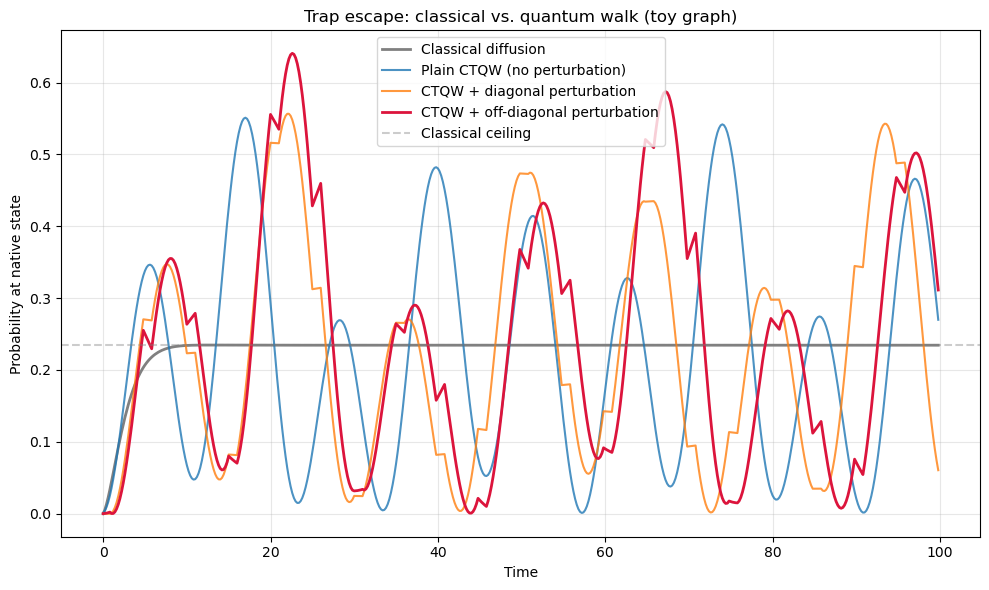

In [19]:
import matplotlib.pyplot as plt

# Reuse your existing trajectories from the last run
t_values = np.arange(0, total_time, dt)

plt.figure(figsize=(10, 6))
plt.plot(t_values, classical_native, label='Classical diffusion', linewidth=2, color='gray')
plt.plot(t_values, plain_native, label='Plain CTQW (no perturbation)', linewidth=1.5, alpha=0.8)
plt.plot(t_values, diag_native, label='CTQW + diagonal perturbation', linewidth=1.5, alpha=0.8)
plt.plot(t_values, offdiag_native, label='CTQW + off-diagonal perturbation', linewidth=2, color='crimson')

plt.axhline(y=max(classical_native), color='gray', linestyle='--', alpha=0.4, label='Classical ceiling')

plt.xlabel('Time')
plt.ylabel('Probability at native state')
plt.title('Trap escape: classical vs. quantum walk (toy graph)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure1_toy_graph.png', dpi=150)
plt.show()

In [20]:
from scipy.signal import find_peaks

def get_peaks(trajectory_values, t_values, min_height=0.1):
    values = np.array(trajectory_values)
    peak_indices, _ = find_peaks(values, height=min_height)
    peak_times = t_values[peak_indices]
    peak_heights = values[peak_indices]
    return peak_times, peak_heights

t_values = np.arange(0, total_time, dt)

plain_peak_t, plain_peak_h = get_peaks(plain_native, t_values)
diag_peak_t, diag_peak_h = get_peaks(diag_native, t_values)
offdiag_peak_t, offdiag_peak_h = get_peaks(offdiag_native, t_values)

print(f"Plain CTQW — {len(plain_peak_h)} peaks, mean height = {plain_peak_h.mean():.3f}, max = {plain_peak_h.max():.3f}")
print(f"Diagonal perturbation — {len(diag_peak_h)} peaks, mean height = {diag_peak_h.mean():.3f}, max = {diag_peak_h.max():.3f}")
print(f"Off-diagonal perturbation — {len(offdiag_peak_h)} peaks, mean height = {offdiag_peak_h.mean():.3f}, max = {offdiag_peak_h.max():.3f}")

# Direct head-to-head: how many cycles does off-diagonal beat plain CTQW?
n_compare = min(len(plain_peak_h), len(offdiag_peak_h))
wins = sum(offdiag_peak_h[:n_compare] > plain_peak_h[:n_compare])
print(f"\nOff-diagonal beats plain CTQW in {wins}/{n_compare} comparable cycles")
print(f"Mean difference (offdiag - plain): {(offdiag_peak_h[:n_compare] - plain_peak_h[:n_compare]).mean():.3f}")

Plain CTQW — 9 peaks, mean height = 0.408, max = 0.551
Diagonal perturbation — 21 peaks, mean height = 0.339, max = 0.556
Off-diagonal perturbation — 20 peaks, mean height = 0.378, max = 0.641

Off-diagonal beats plain CTQW in 5/9 comparable cycles
Mean difference (offdiag - plain): -0.044


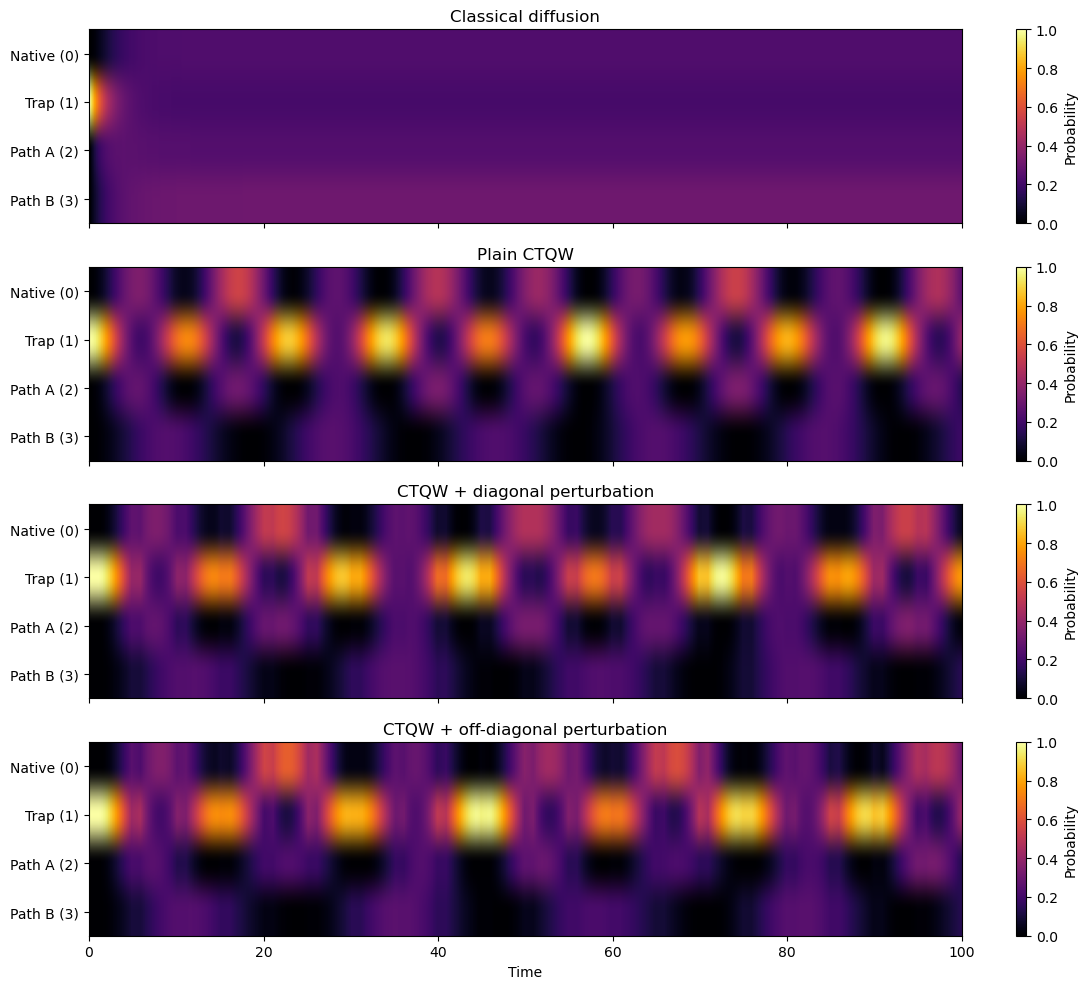

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def build_probability_matrix(trajectory):
    """trajectory: list of (t, prob_vector) -> matrix of shape (n_nodes, n_timesteps)"""
    probs = np.array([p for t, p in trajectory]).T  # shape: (n_nodes, n_timesteps)
    return probs

# Need classical as a trajectory too, for consistent shape
classical_traj = []
for t in np.arange(0, total_time, dt):
    p_t = expm(-L_classical * t) @ p0_trapped
    classical_traj.append((t, p_t))
classical_matrix = build_probability_matrix(classical_traj)

plain_matrix = build_probability_matrix(traj_plain)
diag_matrix = build_probability_matrix(traj_diag)
offdiag_matrix = build_probability_matrix(traj_offdiag)

node_labels = ['Native (0)', 'Trap (1)', 'Path A (2)', 'Path B (3)']

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
matrices = [classical_matrix, plain_matrix, diag_matrix, offdiag_matrix]
titles = ['Classical diffusion', 'Plain CTQW', 'CTQW + diagonal perturbation', 'CTQW + off-diagonal perturbation']

for ax, matrix, title in zip(axes, matrices, titles):
    im = ax.imshow(matrix, aspect='auto', cmap='inferno', 
                    extent=[0, total_time, len(node_labels)-0.5, -0.5],
                    vmin=0, vmax=1)
    ax.set_yticks(range(len(node_labels)))
    ax.set_yticklabels(node_labels)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label='Probability')

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.savefig('probability_landscape_heatmap.png', dpi=150)
plt.show()

In [22]:
def run_ctqw_phase_locked(L_base, perturb_fn, total_time, dt, psi0, trap_node, window=3):
    psi = psi0.copy()
    t = 0.0
    trajectory = []
    trap_history = []  # track recent trap-node probability to detect direction
    
    while t < total_time:
        current_trap_prob = np.abs(psi[trap_node])**2
        trap_history.append(current_trap_prob)
        
        # Determine if trap probability is currently decreasing (outward swing)
        if len(trap_history) >= window:
            recent = trap_history[-window:]
            is_decreasing = recent[-1] < recent[0]
        else:
            is_decreasing = False
        
        L_now = perturb_fn() if is_decreasing else L_base
        psi = expm(-1j * L_now * dt) @ psi
        t += dt
        trajectory.append((t, np.abs(psi)**2))
    
    return trajectory

# Run phase-locked off-diagonal perturbation
traj_phaselocked = run_ctqw_phase_locked(
    L_quantum,
    lambda: perturbation_offdiag(L_quantum, trap_node, 0, strength),
    total_time=100, dt=0.2, psi0=psi0_trapped, trap_node=trap_node, window=3
)
phaselocked_native = [p[0] for t, p in traj_phaselocked]

print(f"Phase-locked off-diagonal: max native prob = {max(phaselocked_native):.3f}, final = {phaselocked_native[-1]:.3f}")

# Compare peaks against plain CTQW, same as before
pl_peak_t, pl_peak_h = get_peaks(phaselocked_native, t_values)
print(f"Phase-locked — {len(pl_peak_h)} peaks, mean height = {pl_peak_h.mean():.3f}, max = {pl_peak_h.max():.3f}")

n_compare = min(len(plain_peak_h), len(pl_peak_h))
wins = sum(pl_peak_h[:n_compare] > plain_peak_h[:n_compare])
print(f"Phase-locked beats plain CTQW in {wins}/{n_compare} comparable cycles")
print(f"Mean difference (phaselocked - plain): {(pl_peak_h[:n_compare] - plain_peak_h[:n_compare]).mean():.3f}")

Phase-locked off-diagonal: max native prob = 0.579, final = 0.186
Phase-locked — 59 peaks, mean height = 0.288, max = 0.579
Phase-locked beats plain CTQW in 0/9 comparable cycles
Mean difference (phaselocked - plain): -0.243
